In [28]:
import torch

X_train = torch.load('/X_train_dl.pt', weights_only=True)
X_val   = torch.load('/X_val_dl.pt',   weights_only=True)
X_test  = torch.load('/X_test_dl.pt',  weights_only=True)
y_train = torch.load('/y_train_dl.pt', weights_only=True)
y_val   = torch.load('/y_val_dl.pt',   weights_only=True)
y_test  = torch.load('/y_test_dl.pt',  weights_only=True)

print(X_train.shape, y_train.shape)

torch.Size([13526, 6]) torch.Size([13526, 1])


In [29]:
from torch.utils.data import DataLoader, TensorDataset

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val,   y_val),   batch_size=64)
test_loader  = DataLoader(TensorDataset(X_test,  y_test),  batch_size=64)

print("DataLoaders ready!")

DataLoaders ready!


In [30]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_size, activation='relu'):
        super().__init__()
        act = {'relu': nn.ReLU(), 'sigmoid': nn.Sigmoid(), 'tanh': nn.Tanh()}[activation]
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            act,
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            act,
            nn.Dropout(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

print("Model defined!")

Model defined!


In [31]:
def train_model(activation, epochs=50, patience=8):
    model = MLP(input_size=6, activation=activation)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.BCELoss()

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_state = None
    no_improve = 0

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss, correct, total = 0, 0, 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(xb)
            correct += ((preds >= 0.5).float() == yb).sum().item()
            total += len(xb)

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                preds = model(xb)
                val_loss += criterion(preds, yb).item() * len(xb)
                val_correct += ((preds >= 0.5).float() == yb).sum().item()
                val_total += len(xb)

        tl = train_loss / total
        vl = val_loss / val_total
        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        history['train_acc'].append(correct / total)
        history['val_acc'].append(val_correct / val_total)

        # Early stopping
        if vl < best_val_loss:
            best_val_loss = vl
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stop at epoch {epoch+1}")
                break

        if (epoch+1) % 10 == 0:
            print(f"  Epoch {epoch+1} | loss={tl:.4f}/{vl:.4f} | acc={correct/total:.4f}/{val_correct/val_total:.4f}")

    model.load_state_dict(best_state)
    return model, history

print("Training function ready!")

Training function ready!


In [32]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

def evaluate(model):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            probs = model(xb).squeeze()
            preds = (probs >= 0.5).float()
            all_preds  += preds.tolist()
            all_probs  += probs.tolist()
            all_labels += yb.squeeze().tolist()

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)

    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall':    recall_score(y_true, y_pred),
        'f1':        f1_score(y_true, y_pred),
        'roc_auc':   roc_auc_score(y_true, y_prob),
        'cm':        confusion_matrix(y_true, y_pred),
        'fpr':       roc_curve(y_true, y_prob)[0],
        'tpr':       roc_curve(y_true, y_prob)[1],
        'y_true':    y_true,
        'y_pred':    y_pred,
        'y_prob':    y_prob,
    }

print("Evaluate function ready!")

Evaluate function ready!


In [33]:
activations = ['relu', 'tanh', 'sigmoid']
results = {}
histories = {}

for act in activations:
    print(f"\n=== Training MLP ({act.upper()}) ===")
    model, history = train_model(act)
    results[act]   = evaluate(model)
    histories[act] = history
    r = results[act]
    print(f"  Accuracy={r['accuracy']:.4f} | Recall={r['recall']:.4f} | F1={r['f1']:.4f} | AUC={r['roc_auc']:.4f}")


=== Training MLP (RELU) ===
  Epoch 10 | loss=0.2579/0.2597 | acc=0.8976/0.8887
  Epoch 20 | loss=0.2119/0.2291 | acc=0.9189/0.8980
  Early stop at epoch 30
  Accuracy=0.9093 | Recall=0.9020 | F1=0.4035 | AUC=0.9746

=== Training MLP (TANH) ===
  Epoch 10 | loss=0.3351/0.2824 | acc=0.8532/0.8880
  Epoch 20 | loss=0.3040/0.2754 | acc=0.8694/0.8807
  Early stop at epoch 27
  Accuracy=0.9120 | Recall=0.8431 | F1=0.3945 | AUC=0.9500

=== Training MLP (SIGMOID) ===
  Epoch 10 | loss=0.5015/0.4758 | acc=0.7774/0.8460
  Epoch 20 | loss=0.4701/0.4248 | acc=0.7967/0.8800
  Early stop at epoch 24
  Accuracy=0.8953 | Recall=0.7647 | F1=0.3319 | AUC=0.8199


In [34]:
print(f"\n{'Model':<18} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'ROC-AUC':>9}")
print("="*60)
for act in activations:
    r = results[act]
    print(f"MLP ({act:<8}) {r['accuracy']:>9.4f} {r['precision']:>10.4f} {r['recall']:>8.4f} {r['f1']:>8.4f} {r['roc_auc']:>9.4f}")


Model               Accuracy  Precision   Recall       F1   ROC-AUC
MLP (relu    )    0.9093     0.2599   0.9020   0.4035    0.9746
MLP (tanh    )    0.9120     0.2575   0.8431   0.3945    0.9500
MLP (sigmoid )    0.8953     0.2120   0.7647   0.3319    0.8199


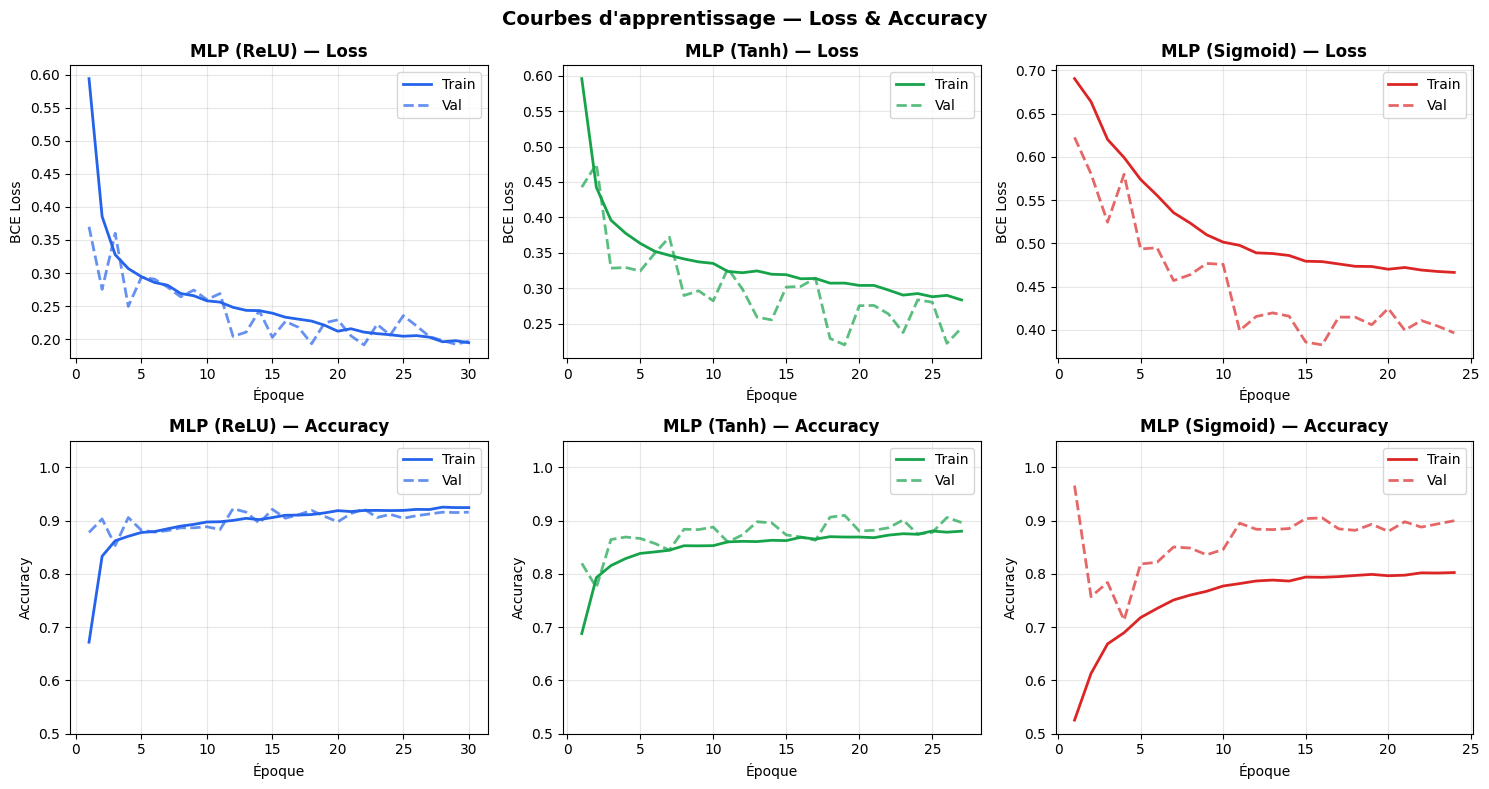

In [35]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Courbes d'apprentissage — Loss & Accuracy", fontsize=14, fontweight='bold')

colors = {'relu': '#2563EB', 'tanh': '#16A34A', 'sigmoid': '#DC2626'}
labels = {'relu': 'MLP (ReLU)', 'tanh': 'MLP (Tanh)', 'sigmoid': 'MLP (Sigmoid)'}

for col, act in enumerate(activations):
    h = histories[act]
    ep = range(1, len(h['train_loss']) + 1)
    c = colors[act]

    # Loss
    axes[0, col].plot(ep, h['train_loss'], color=c, lw=2, label='Train')
    axes[0, col].plot(ep, h['val_loss'],   color=c, lw=2, linestyle='--', alpha=0.7, label='Val')
    axes[0, col].set_title(f"{labels[act]} — Loss", fontweight='bold')
    axes[0, col].set_xlabel('Époque')
    axes[0, col].set_ylabel('BCE Loss')
    axes[0, col].legend()
    axes[0, col].grid(True, alpha=0.3)

    # Accuracy
    axes[1, col].plot(ep, h['train_acc'], color=c, lw=2, label='Train')
    axes[1, col].plot(ep, h['val_acc'],   color=c, lw=2, linestyle='--', alpha=0.7, label='Val')
    axes[1, col].set_title(f"{labels[act]} — Accuracy", fontweight='bold')
    axes[1, col].set_xlabel('Époque')
    axes[1, col].set_ylabel('Accuracy')
    axes[1, col].set_ylim(0.5, 1.05)
    axes[1, col].legend()
    axes[1, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig1_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

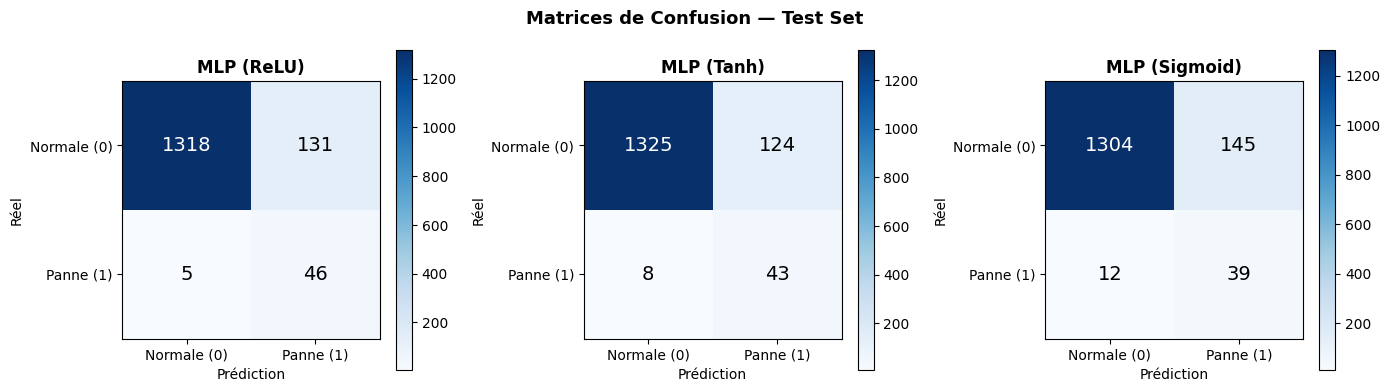

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Matrices de Confusion — Test Set', fontsize=13, fontweight='bold')

for col, act in enumerate(activations):
    cm = results[act]['cm']
    ax = axes[col]
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(labels[act], fontweight='bold')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Normale (0)', 'Panne (1)'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Normale (0)', 'Panne (1)'])
    ax.set_xlabel('Prédiction')
    ax.set_ylabel('Réel')
    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=14,
                    color='white' if cm[i, j] > thresh else 'black')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig('fig2_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

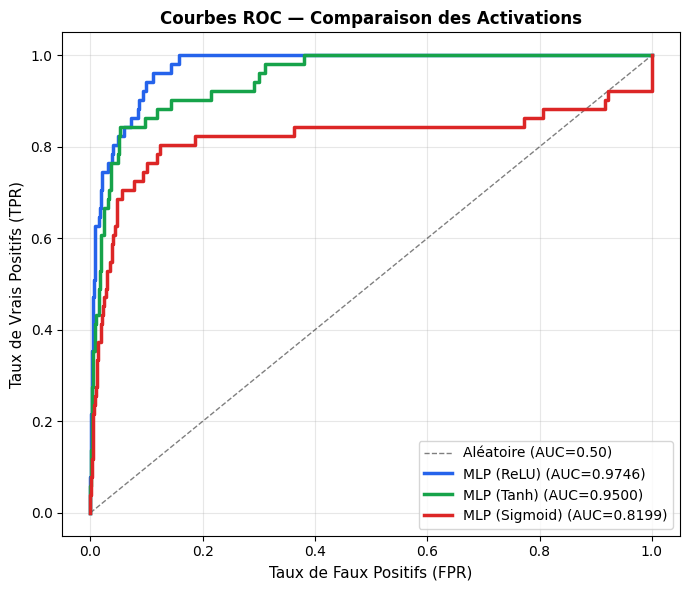

In [37]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Aléatoire (AUC=0.50)')

for act in activations:
    fpr = results[act]['fpr']
    tpr = results[act]['tpr']
    auc = results[act]['roc_auc']
    ax.plot(fpr, tpr, color=colors[act], lw=2.5, label=f"{labels[act]} (AUC={auc:.4f})")

ax.set_xlabel('Taux de Faux Positifs (FPR)', fontsize=11)
ax.set_ylabel('Taux de Vrais Positifs (TPR)', fontsize=11)
ax.set_title('Courbes ROC — Comparaison des Activations', fontsize=12, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig3_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1420/1829355782.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


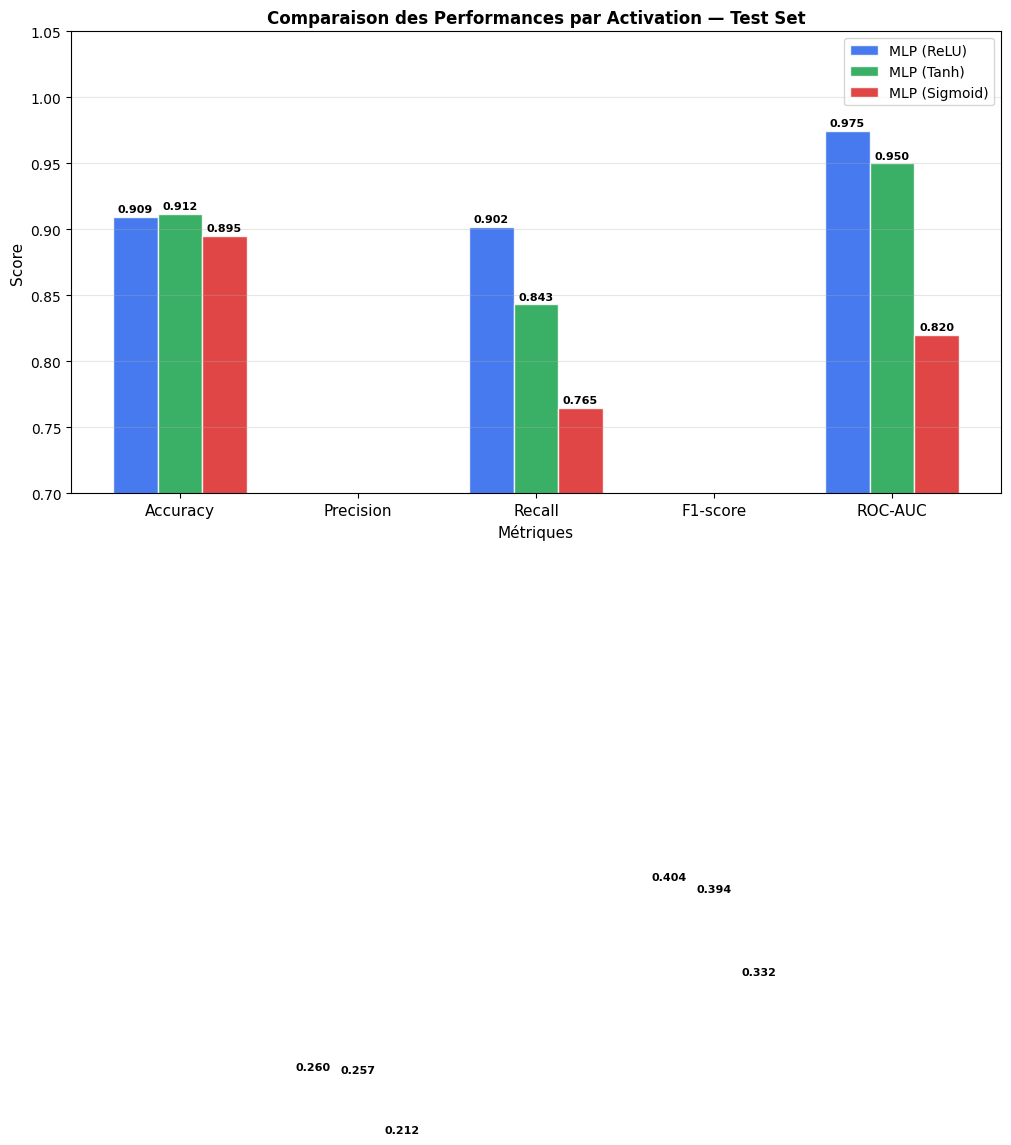

In [38]:
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
metric_keys  = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

x = np.arange(len(metric_names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
for i, act in enumerate(activations):
    vals = [results[act][k] for k in metric_keys]
    bars = ax.bar(x + i * width, vals, width, label=labels[act],
                  color=colors[act], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Métriques', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Comparaison des Performances par Activation — Test Set', fontsize=12, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0.7, 1.05)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig4_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()